# Graph Neural Operator + Gray-Scott + Deep Ensembles

This notebook introduces a **graph-based neural operator** for a Gray-Scott
reaction-diffusion system. The main model is `GraphNeuralOperator2D`, which
views a regular grid as a graph and performs local message passing on node
embeddings.

## What this notebook does

- predicts one-step-ahead Gray-Scott fields,
- uses **deep ensembles** as the primary uncertainty method,
- compares in-domain and OOD pattern regimes,
- optionally fits a **last-layer Laplace** approximation for a cheaper Bayesian
  baseline.

The intended external dataset is **The Well Gray-Scott reaction-diffusion
benchmark**. For local execution and CI smoke tests, this notebook falls back
to a small synthetic Gray-Scott generator if a local The Well archive is not
available.


In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / 'src').exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))


In [2]:
import math
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from deepuq.data import load_gray_scott_pairs, split_gray_scott_pairs_by_regime
from deepuq.methods import DeepEnsembleWrapper, LaplaceWrapper
from deepuq.models import GraphNeuralOperator2D

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['image.cmap'] = 'viridis'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(7)
np.random.seed(7)
print('device:', device)


device: cuda


## Configuration

This notebook exposes two execution modes:

- **quick mode**: CPU-friendly synthetic fallback, small grid, short training
- **full mode**: expects a local The Well Gray-Scott archive and uses a larger
  split / longer training schedule

`DEEPUQ_NOTEBOOK_QUICK=1` forces quick mode automatically in smoke tests.


In [3]:
quick_mode = os.environ.get('DEEPUQ_NOTEBOOK_QUICK', '0') == '1'

config = {
    'quick_mode': quick_mode,
    'dataset_root': os.environ.get('DEEPUQ_THE_WELL_ROOT', ''),
    'force_synthetic': quick_mode,
    'resolution': 20 if quick_mode else 24,
    'train_per_regime': 18 if quick_mode else 28,
    'val_per_regime': 8 if quick_mode else 12,
    'test_per_regime': 16 if quick_mode else 24,
    'ood_per_regime': 8 if quick_mode else 16,
    'batch_size': 6 if quick_mode else 8,
    'epochs': 25 if quick_mode else 40,
    'ensemble_members': 4,
    'lr': 1.5e-3,
    'weight_decay': 1e-5,
    'radius': 1,
    'hidden_dim': 48 if quick_mode else 64,
    'message_dim': 48 if quick_mode else 64,
    'message_steps': 4,
    'laplace_prior_precision': 40.0,
    'laplace_samples': 8 if quick_mode else 16,
    'run_optional_laplace': True,
}
config


{'quick_mode': False,
 'dataset_root': '',
 'force_synthetic': False,
 'resolution': 24,
 'train_per_regime': 28,
 'val_per_regime': 12,
 'test_per_regime': 24,
 'ood_per_regime': 16,
 'batch_size': 8,
 'epochs': 40,
 'ensemble_members': 4,
 'lr': 0.0015,
 'weight_decay': 1e-05,
 'radius': 1,
 'hidden_dim': 64,
 'message_dim': 64,
 'message_steps': 4,
 'laplace_prior_precision': 40.0,
 'laplace_samples': 16,
 'run_optional_laplace': True}

## Physical problem

The Gray-Scott system models two reacting and diffusing chemical species,
traditionally written as concentrations $A(x, y, t)$ and $B(x, y, t)$.
Pattern formation emerges from the interaction between:

- diffusion of both species,
- nonlinear reaction terms,
- feed rate $f$,
- kill rate $k$.

In this notebook the learning task is:

$$
[A(x,y,t), B(x,y,t)] \mapsto [A(x,y,t+\Delta t), B(x,y,t+\Delta t)].
$$

So the **input** is one 2-channel field, and the **output** is the next 2-channel field.

### Why a graph model on a grid?

Even though the data lives on a regular lattice, graph operators are useful when:

- you want local message passing instead of spectral convolutions,
- you want a modeling path that can later transfer to irregular meshes,
- you want to compare graph inductive bias against FNO/U-Net style surrogates.


In [4]:
def laplacian_periodic(u: torch.Tensor) -> torch.Tensor:
    return (
        torch.roll(u, 1, dims=0)
        + torch.roll(u, -1, dims=0)
        + torch.roll(u, 1, dims=1)
        + torch.roll(u, -1, dims=1)
        - 4.0 * u
    )


def _initial_gray_scott_fields(
    resolution: int,
    *,
    mode: str,
    generator: torch.Generator,
) -> tuple[torch.Tensor, torch.Tensor]:
    grid = torch.linspace(0.0, 1.0, resolution)
    xx, yy = torch.meshgrid(grid, grid, indexing='ij')
    species_a = torch.ones(resolution, resolution)
    species_b = torch.zeros(resolution, resolution)

    if mode == 'blob':
        cx = 0.35 + 0.30 * torch.rand(1, generator=generator).item()
        cy = 0.35 + 0.30 * torch.rand(1, generator=generator).item()
        sigma = 0.05 + 0.03 * torch.rand(1, generator=generator).item()
        blob = torch.exp(-((xx - cx) ** 2 + (yy - cy) ** 2) / (2.0 * sigma**2))
        species_b += 0.35 * blob
        species_a -= 0.45 * blob
    elif mode == 'two_blob':
        for cx, cy in [(0.30, 0.32), (0.70, 0.65)]:
            sigma = 0.04 + 0.02 * torch.rand(1, generator=generator).item()
            blob = torch.exp(-((xx - cx) ** 2 + (yy - cy) ** 2) / (2.0 * sigma**2))
            species_b += 0.24 * blob
            species_a -= 0.25 * blob
    elif mode == 'stripe':
        phase = 2.0 * math.pi * torch.rand(1, generator=generator).item()
        stripe = 0.18 * 0.5 * (1.0 + torch.sin(2.0 * math.pi * 4.0 * xx + phase))
        species_b += stripe
        species_a -= 0.15 * stripe / 0.18
    else:
        raise ValueError(f'Unknown initialization mode: {mode}')

    species_a = (species_a + 0.01 * torch.randn((resolution, resolution), generator=generator)).clamp(0.0, 1.2)
    species_b = (species_b + 0.01 * torch.randn((resolution, resolution), generator=generator)).clamp(0.0, 1.0)
    return species_a, species_b


def simulate_gray_scott_pair(
    feed_rate: float,
    kill_rate: float,
    *,
    resolution: int,
    mode: str,
    steps_before_pair: int = 10,
    prediction_horizon: int = 2,
    dt: float = 0.35,
    diffusion_a: float = 1.0,
    diffusion_b: float = 0.5,
    generator: torch.Generator,
) -> tuple[torch.Tensor, torch.Tensor]:
    species_a, species_b = _initial_gray_scott_fields(
        resolution,
        mode=mode,
        generator=generator,
    )

    for _ in range(steps_before_pair):
        reaction = species_a * species_b.square()
        species_a = species_a + dt * (
            diffusion_a * laplacian_periodic(species_a)
            - reaction
            + feed_rate * (1.0 - species_a)
        )
        species_b = species_b + dt * (
            diffusion_b * laplacian_periodic(species_b)
            + reaction
            - (kill_rate + feed_rate) * species_b
        )
        species_a = species_a.clamp(0.0, 1.4)
        species_b = species_b.clamp(0.0, 1.4)

    current_state = torch.stack((species_a, species_b), dim=-1)

    for _ in range(prediction_horizon):
        reaction = species_a * species_b.square()
        species_a = species_a + dt * (
            diffusion_a * laplacian_periodic(species_a)
            - reaction
            + feed_rate * (1.0 - species_a)
        )
        species_b = species_b + dt * (
            diffusion_b * laplacian_periodic(species_b)
            + reaction
            - (kill_rate + feed_rate) * species_b
        )
        species_a = species_a.clamp(0.0, 1.4)
        species_b = species_b.clamp(0.0, 1.4)

    next_state = torch.stack((species_a, species_b), dim=-1)
    return current_state, next_state


@dataclass
class SplitTensors:
    train_x: torch.Tensor
    train_y: torch.Tensor
    val_x: torch.Tensor
    val_y: torch.Tensor
    test_x: torch.Tensor
    test_y: torch.Tensor
    ood_x: torch.Tensor
    ood_y: torch.Tensor
    summary: dict


def make_synthetic_gray_scott_splits(cfg: dict) -> SplitTensors:
    resolution = cfg['resolution']
    train_regimes = [(0.020, 0.049), (0.022, 0.051), (0.024, 0.053)]
    test_regimes = [(0.023, 0.052)]
    ood_regimes = [(0.038, 0.062), (0.044, 0.067)]

    def build(regimes, n_per_regime, mode, seed):
        generator = torch.Generator().manual_seed(seed)
        inputs = []
        targets = []
        for feed_rate, kill_rate in regimes:
            for _ in range(n_per_regime):
                current_state, next_state = simulate_gray_scott_pair(
                    feed_rate,
                    kill_rate,
                    resolution=resolution,
                    mode=mode,
                    generator=generator,
                )
                inputs.append(current_state)
                targets.append(next_state)
        return torch.stack(inputs), torch.stack(targets)

    train_x, train_y = build(train_regimes, cfg['train_per_regime'], 'blob', seed=7)
    val_x, val_y = build(test_regimes, cfg['val_per_regime'], 'blob', seed=17)
    test_x, test_y = build(test_regimes, cfg['test_per_regime'], 'blob', seed=23)
    ood_x, ood_y = build(ood_regimes, cfg['ood_per_regime'], 'stripe', seed=31)

    return SplitTensors(
        train_x=train_x,
        train_y=train_y,
        val_x=val_x,
        val_y=val_y,
        test_x=test_x,
        test_y=test_y,
        ood_x=ood_x,
        ood_y=ood_y,
        summary={
            'source': 'synthetic Gray-Scott fallback',
            'train_regimes': train_regimes,
            'test_regimes': test_regimes,
            'ood_regimes': ood_regimes,
            'ood_pattern_family': 'stripe',
        },
    )


def make_the_well_splits(cfg: dict) -> SplitTensors:
    root = cfg['dataset_root']
    pairs = load_gray_scott_pairs(root)
    unique_regimes = sorted({(round(float(f), 6), round(float(k), 6)) for f, k in zip(pairs.feed_rates.tolist(), pairs.kill_rates.tolist())})
    if len(unique_regimes) < 5:
        raise ValueError('Expected at least five distinct Gray-Scott regimes in the local The Well subset.')
    train_regimes = unique_regimes[:-2]
    ood_regimes = unique_regimes[-2:]
    split = split_gray_scott_pairs_by_regime(
        pairs,
        train_regimes=train_regimes,
        ood_regimes=ood_regimes,
        val_fraction=0.15,
        test_fraction=0.15,
        seed=7,
    )
    return SplitTensors(
        train_x=split['train'].current_states,
        train_y=split['train'].next_states,
        val_x=split['val'].current_states,
        val_y=split['val'].next_states,
        test_x=split['test'].current_states,
        test_y=split['test'].next_states,
        ood_x=split['ood'].current_states,
        ood_y=split['ood'].next_states,
        summary={
            'source': f'local The Well archive at {root}',
            'train_regimes': train_regimes,
            'ood_regimes': ood_regimes,
        },
    )


def load_or_generate_gray_scott(cfg: dict) -> SplitTensors:
    dataset_root = cfg['dataset_root']
    if dataset_root and not cfg['force_synthetic']:
        dataset_path = Path(dataset_root).expanduser()
        if dataset_path.exists():
            return make_the_well_splits(cfg)
        raise FileNotFoundError(
            f'DEEPUQ_THE_WELL_ROOT={dataset_root!r} does not exist. '            'Either point it at a local Gray-Scott archive or enable quick synthetic mode.'
        )
    return make_synthetic_gray_scott_splits(cfg)


## Dataset loading

The preferred path is a **local The Well Gray-Scott archive**. That is what you
would use for a real dataset study.

For local smoke tests and self-contained execution, the notebook falls back to a
small synthetic Gray-Scott generator that preserves the important scientific UQ
story:

- **in-domain**: smoother blob-like patterns from a narrow regime set,
- **OOD**: held-out regimes with sharper stripe-like patterns.


In [5]:
splits = load_or_generate_gray_scott(config)
print(splits.summary)
for name, tensor in {
    'train_x': splits.train_x,
    'train_y': splits.train_y,
    'test_x': splits.test_x,
    'ood_x': splits.ood_x,
}.items():
    print(name, tuple(tensor.shape))


{'source': 'synthetic Gray-Scott fallback', 'train_regimes': [(0.02, 0.049), (0.022, 0.051), (0.024, 0.053)], 'test_regimes': [(0.023, 0.052)], 'ood_regimes': [(0.038, 0.062), (0.044, 0.067)], 'ood_pattern_family': 'stripe'}
train_x (84, 24, 24, 2)
train_y (84, 24, 24, 2)
test_x (24, 24, 24, 2)
ood_x (32, 24, 24, 2)


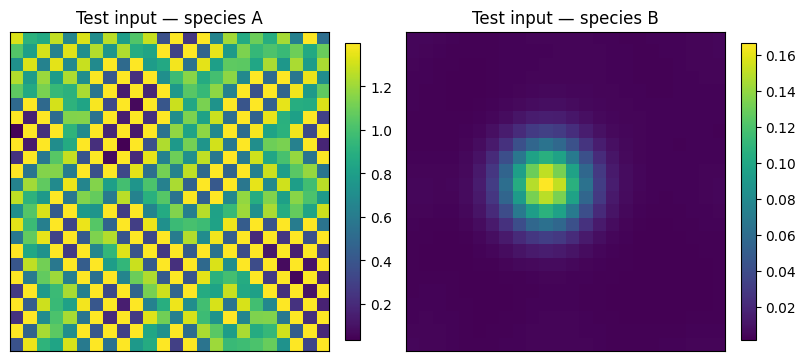

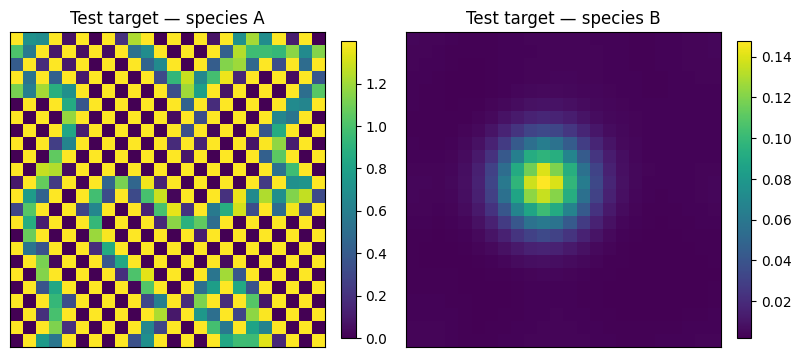

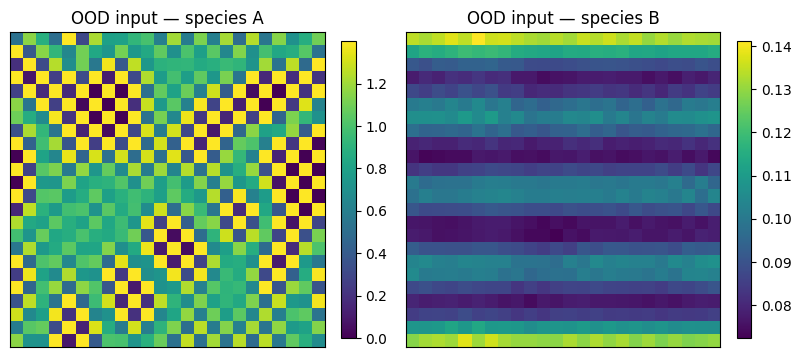

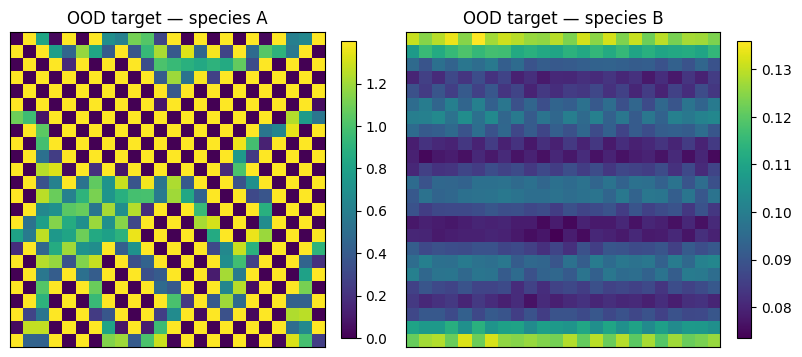

In [7]:
def plot_state_channels(state: torch.Tensor, title_prefix: str) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), constrained_layout=True)
    im0 = axes[0].imshow(state[..., 0].cpu())
    axes[0].set_title(f'{title_prefix} — species A')
    plt.colorbar(im0, ax=axes[0], fraction=0.046)
    im1 = axes[1].imshow(state[..., 1].cpu())
    axes[1].set_title(f'{title_prefix} — species B')
    plt.colorbar(im1, ax=axes[1], fraction=0.046)
    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])
    plt.show()

plot_state_channels(splits.test_x[0], 'Test input')
plot_state_channels(splits.test_y[0], 'Test target')
plot_state_channels(splits.ood_x[0], 'OOD input')
plot_state_channels(splits.ood_y[0], 'OOD target')


## Graph construction on the grid

`GraphNeuralOperator2D` turns the regular lattice into a graph:

- one node per grid cell,
- local radius-based edges,
- node features = two Gray-Scott species + coordinates,
- edge features = relative offsets and distance.

This gives a local message-passing operator that can later extend naturally to
unstructured scientific meshes.


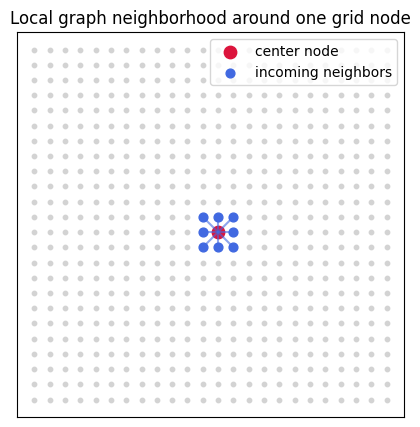

In [8]:
demo_model = GraphNeuralOperator2D(
    in_channels=2,
    hidden_dim=config['hidden_dim'],
    message_dim=config['message_dim'],
    n_message_passing_steps=config['message_steps'],
    out_channels=2,
    radius=config['radius'],
)

graph = demo_model._build_graph(
    splits.train_x.shape[1],
    splits.train_x.shape[2],
    device=torch.device('cpu'),
    dtype=torch.float32,
)
center = (splits.train_x.shape[1] // 2) * splits.train_x.shape[2] + (splits.train_x.shape[2] // 2)
mask = graph.dst == center
src = graph.src[mask]
coords = graph.coords

plt.figure(figsize=(5, 5))
plt.scatter(coords[:, 1], coords[:, 0], s=10, color='lightgray')
plt.scatter(coords[center, 1], coords[center, 0], s=80, color='crimson', label='center node')
plt.scatter(coords[src, 1], coords[src, 0], s=40, color='royalblue', label='incoming neighbors')
for idx in src.tolist():
    plt.plot([coords[idx, 1], coords[center, 1]], [coords[idx, 0], coords[center, 0]], color='royalblue', alpha=0.6)
plt.gca().invert_yaxis()
plt.legend(loc='upper right')
plt.title('Local graph neighborhood around one grid node')
plt.xticks([])
plt.yticks([])
plt.show()


## Model and training strategy

To stabilize training, the graph operator is used in a **residual form**:

$$
\hat y = x + lpha \, \delta_	heta(x),
$$

where `x` is the current two-species field and `δ_θ(x)` is the learned
correction. This keeps the model close to an identity update at initialization,
which is a natural inductive bias for one-step time forecasting.

The ensemble is trained with bootstrap resampling. This is useful here because
it increases ensemble diversity and produces a cleaner uncertainty signal on
held-out Gray-Scott regimes.


In [9]:
class ResidualGraphOperator(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.core = GraphNeuralOperator2D(
            in_channels=2,
            hidden_dim=config['hidden_dim'],
            message_dim=config['message_dim'],
            n_message_passing_steps=config['message_steps'],
            out_channels=2,
            radius=config['radius'],
        )
        self.residual_scale = nn.Parameter(torch.tensor(0.15))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.residual_scale * self.core(x)


def rmse(prediction: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    return torch.mean((prediction - target) ** 2).sqrt()


def relative_l2(prediction: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    numerator = torch.norm((prediction - target).reshape(prediction.shape[0], -1), dim=1)
    denominator = torch.norm(target.reshape(target.shape[0], -1), dim=1).clamp_min(1e-6)
    return (numerator / denominator).mean()


def train_bootstrap_ensemble(
    train_x: torch.Tensor,
    train_y: torch.Tensor,
    val_x: torch.Tensor,
    val_y: torch.Tensor,
    cfg: dict,
) -> tuple[DeepEnsembleWrapper, list[dict[str, list[float]]]]:
    models = [ResidualGraphOperator().to(device) for _ in range(cfg['ensemble_members'])]
    histories: list[dict[str, list[float]]] = []
    for member_idx, model in enumerate(models):
        generator = torch.Generator().manual_seed(100 + member_idx)
        bootstrap_idx = torch.randint(0, train_x.size(0), (train_x.size(0),), generator=generator)
        loader = DataLoader(
            TensorDataset(train_x[bootstrap_idx], train_y[bootstrap_idx]),
            batch_size=cfg['batch_size'],
            shuffle=True,
        )
        optimizer = torch.optim.AdamW(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg['epochs'])
        history = {'train_rmse': [], 'val_rmse': [], 'val_rel_l2': []}
        best_state = None
        best_val = float('inf')
        for epoch in range(cfg['epochs']):
            model.train()
            batch_losses = []
            for xb, yb in loader:
                xb = xb.to(device)
                yb = yb.to(device)
                optimizer.zero_grad(set_to_none=True)
                prediction = model(xb)
                loss = torch.nn.functional.mse_loss(prediction, yb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                batch_losses.append(float(loss.detach().sqrt().cpu()))
            scheduler.step()
            model.eval()
            with torch.inference_mode():
                val_prediction = model(val_x.to(device))
                val_rmse = float(rmse(val_prediction, val_y.to(device)).cpu())
                val_rel = float(relative_l2(val_prediction, val_y.to(device)).cpu())
            train_rmse = float(np.mean(batch_losses)) if batch_losses else float('nan')
            history['train_rmse'].append(train_rmse)
            history['val_rmse'].append(val_rmse)
            history['val_rel_l2'].append(val_rel)
            if val_rmse < best_val:
                best_val = val_rmse
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        if best_state is not None:
            model.load_state_dict(best_state)
        histories.append(history)
    return DeepEnsembleWrapper(models), histories


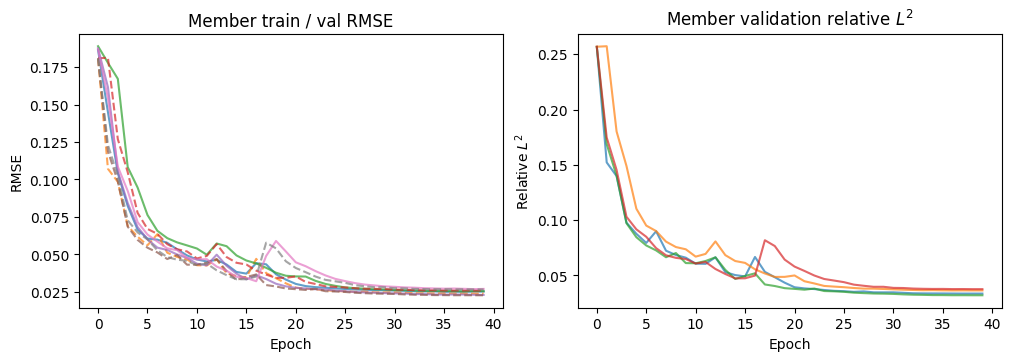

In [10]:
ensemble, histories = train_bootstrap_ensemble(
    splits.train_x,
    splits.train_y,
    splits.val_x,
    splits.val_y,
    config,
)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)
for history in histories:
    axes[0].plot(history['train_rmse'], alpha=0.7)
    axes[0].plot(history['val_rmse'], linestyle='--', alpha=0.7)
    axes[1].plot(history['val_rel_l2'], alpha=0.7)
axes[0].set_title('Member train / val RMSE')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('RMSE')
axes[1].set_title('Member validation relative $L^2$')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Relative $L^2$')
plt.show()


## Ensemble prediction and uncertainty

For the ensemble, the main uncertainty quantity is the **between-member
variance**:

$$
\mathrm{Var}_{	ext{ens}}[y\mid x] = 
rac{1}{M}\sum_{m=1}^M \left(f_{	heta_m}(x) - ar f(x)
ight)^2,
$$

where $ar f(x)$ is the ensemble mean. In this notebook we inspect the fieldwise
standard deviation for both species $A$ and $B$.


In [11]:
uq_test = ensemble.predict_uq(splits.test_x.to(device))
uq_ood = ensemble.predict_uq(splits.ood_x.to(device))

pred_test = uq_test.mean.detach().cpu()
pred_ood = uq_ood.mean.detach().cpu()
std_test = uq_test.epistemic_var.sqrt().detach().cpu()
std_ood = uq_ood.epistemic_var.sqrt().detach().cpu()

metrics = {
    'test_rmse': float(rmse(pred_test, splits.test_y).cpu()),
    'ood_rmse': float(rmse(pred_ood, splits.ood_y).cpu()),
    'test_rel_l2': float(relative_l2(pred_test, splits.test_y).cpu()),
    'ood_rel_l2': float(relative_l2(pred_ood, splits.ood_y).cpu()),
    'test_mean_std': float(std_test.mean().cpu()),
    'ood_mean_std': float(std_ood.mean().cpu()),
}
print(metrics)
metrics


{'test_rmse': 0.02643895335495472, 'ood_rmse': 0.030717844143509865, 'test_rel_l2': 0.03717124089598656, 'ood_rel_l2': 0.04392232745885849, 'test_mean_std': 0.004667469300329685, 'ood_mean_std': 0.0065916371531784534}


{'test_rmse': 0.02643895335495472,
 'ood_rmse': 0.030717844143509865,
 'test_rel_l2': 0.03717124089598656,
 'ood_rel_l2': 0.04392232745885849,
 'test_mean_std': 0.004667469300329685,
 'ood_mean_std': 0.0065916371531784534}

In [12]:
assert metrics['ood_mean_std'] > metrics['test_mean_std'], (
    'The held-out Gray-Scott regime should produce larger ensemble uncertainty than the in-domain test split.'
)
metrics


{'test_rmse': 0.02643895335495472,
 'ood_rmse': 0.030717844143509865,
 'test_rel_l2': 0.03717124089598656,
 'ood_rel_l2': 0.04392232745885849,
 'test_mean_std': 0.004667469300329685,
 'ood_mean_std': 0.0065916371531784534}

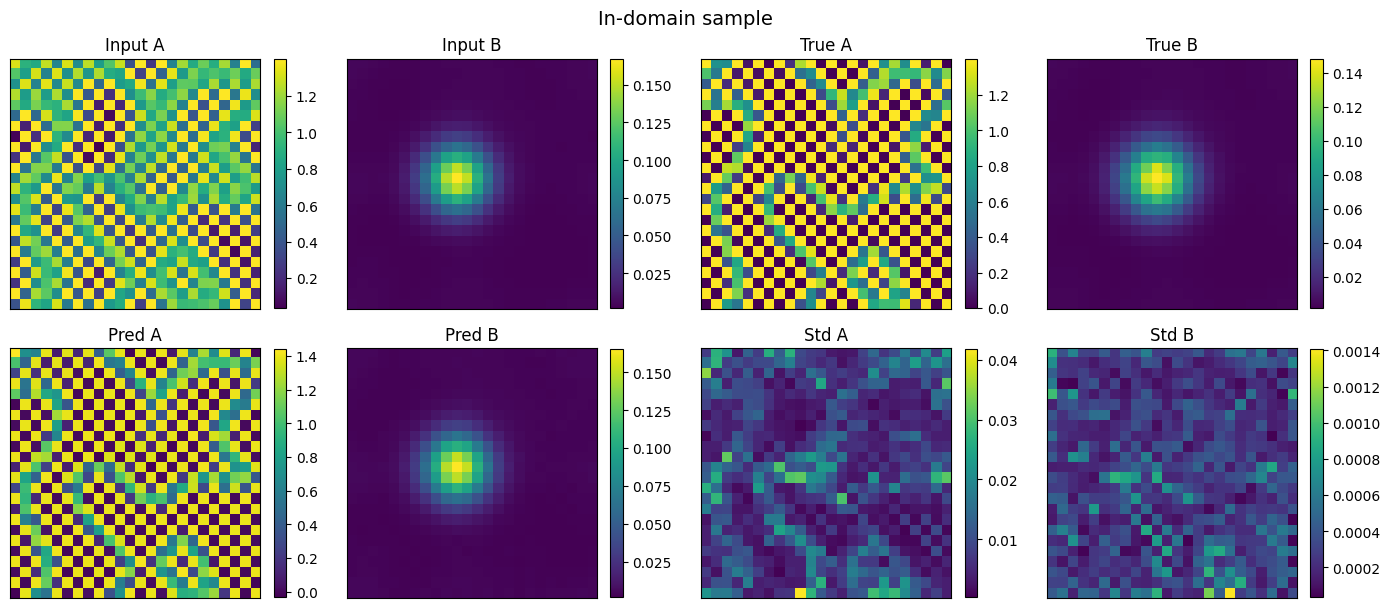

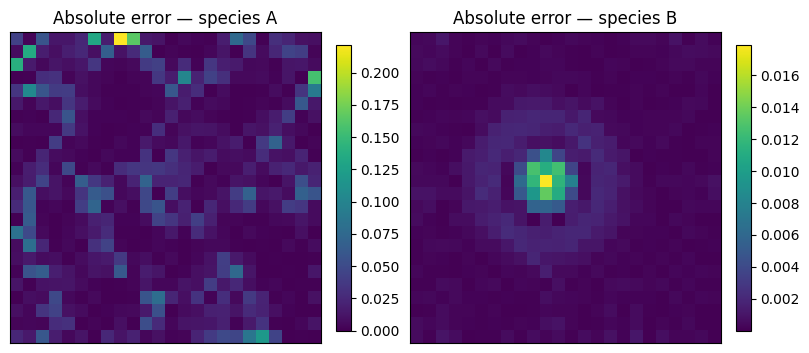

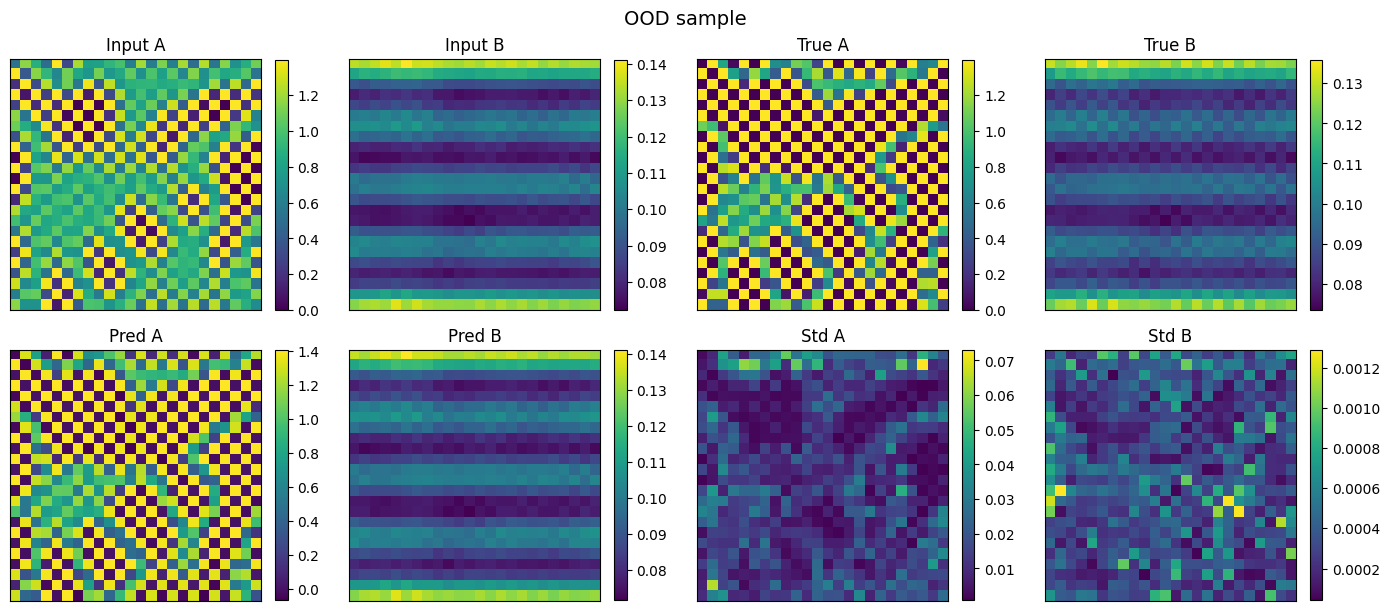

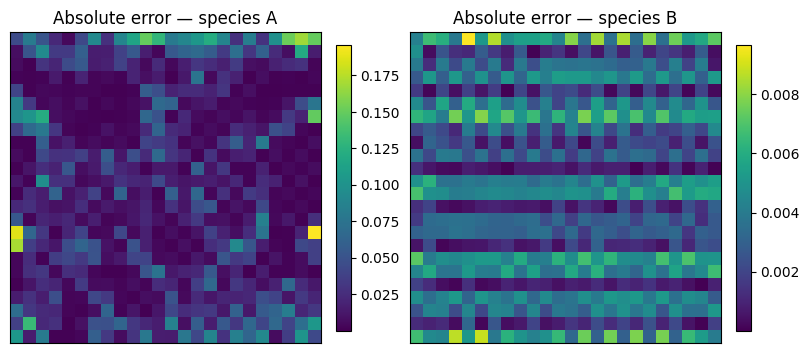

In [13]:
def plot_prediction_bundle(
    current_state: torch.Tensor,
    target_state: torch.Tensor,
    prediction: torch.Tensor,
    std_field: torch.Tensor,
    title: str,
) -> None:
    abs_err = (prediction - target_state).abs()
    fig, axes = plt.subplots(2, 4, figsize=(14, 6), constrained_layout=True)
    panels = [
        ('Input A', current_state[..., 0]),
        ('Input B', current_state[..., 1]),
        ('True A', target_state[..., 0]),
        ('True B', target_state[..., 1]),
        ('Pred A', prediction[..., 0]),
        ('Pred B', prediction[..., 1]),
        ('Std A', std_field[..., 0]),
        ('Std B', std_field[..., 1]),
    ]
    for ax, (panel_title, panel) in zip(axes.flat, panels):
        im = ax.imshow(panel.cpu())
        ax.set_title(panel_title)
        ax.set_xticks([])
        ax.set_yticks([])
        plt.colorbar(im, ax=ax, fraction=0.046)
    fig.suptitle(title, fontsize=14)
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), constrained_layout=True)
    for ax, channel_idx in zip(axes, [0, 1]):
        im = ax.imshow(abs_err[..., channel_idx].cpu())
        ax.set_title(f'Absolute error — species {"AB"[channel_idx]}')
        ax.set_xticks([])
        ax.set_yticks([])
        plt.colorbar(im, ax=ax, fraction=0.046)
    plt.show()

plot_prediction_bundle(splits.test_x[0], splits.test_y[0], pred_test[0], std_test[0], 'In-domain sample')
plot_prediction_bundle(splits.ood_x[0], splits.ood_y[0], pred_ood[0], std_ood[0], 'OOD sample')


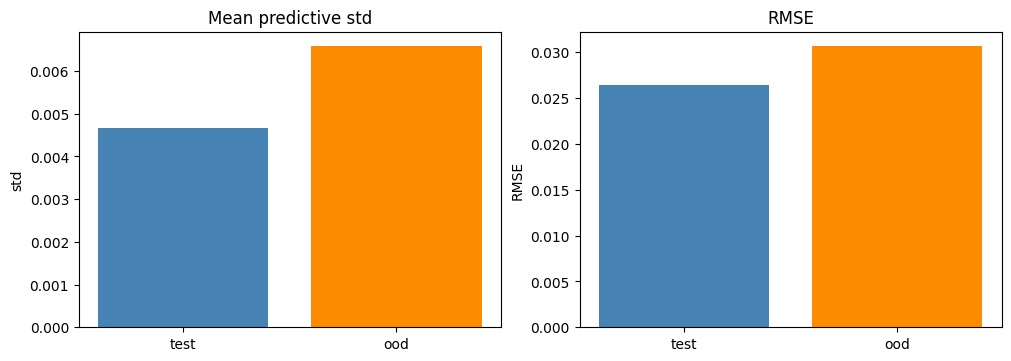

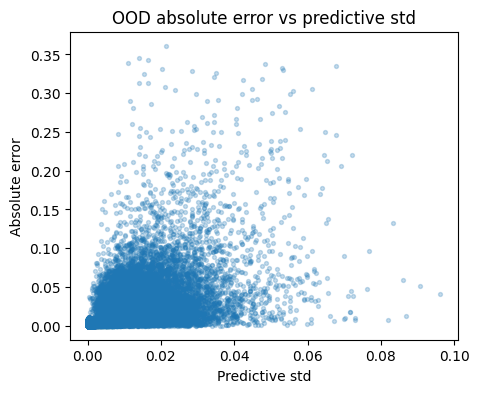

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)
axes[0].bar(['test', 'ood'], [metrics['test_mean_std'], metrics['ood_mean_std']], color=['steelblue', 'darkorange'])
axes[0].set_title('Mean predictive std')
axes[0].set_ylabel('std')
axes[1].bar(['test', 'ood'], [metrics['test_rmse'], metrics['ood_rmse']], color=['steelblue', 'darkorange'])
axes[1].set_title('RMSE')
axes[1].set_ylabel('RMSE')
plt.show()

error_flat = (pred_ood - splits.ood_y).abs().reshape(-1)
std_flat = std_ood.reshape(-1)
plt.figure(figsize=(5, 4))
plt.scatter(std_flat.numpy(), error_flat.numpy(), s=8, alpha=0.25)
plt.xlabel('Predictive std')
plt.ylabel('Absolute error')
plt.title('OOD absolute error vs predictive std')
plt.show()


## Optional last-layer Laplace comparison

Deep ensembles are the primary UQ method here. The optional Laplace section
keeps only the final linear decoder Bayesian and treats the message-passing body
as deterministic. This is a cheaper approximation and a useful baseline.


In [15]:
if config['run_optional_laplace']:
    laplace_model = ResidualGraphOperator().to(device)
    train_loader = DataLoader(TensorDataset(splits.train_x, splits.train_y), batch_size=config['batch_size'], shuffle=True)
    optimizer = torch.optim.AdamW(laplace_model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    for _ in range(max(config['epochs'] // 2, 8)):
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad(set_to_none=True)
            prediction = laplace_model(xb)
            loss = torch.nn.functional.mse_loss(prediction, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(laplace_model.parameters(), 1.0)
            optimizer.step()

    la = LaplaceWrapper(
        laplace_model,
        likelihood='regression',
        subset_of_weights='last_layer',
        hessian_structure='block_diag',
    )
    la.fit(train_loader, prior_precision=config['laplace_prior_precision'])
    uq_laplace_test = la.predict_uq(splits.test_x[: min(6, splits.test_x.size(0))].to(device), n_samples=config['laplace_samples'])
    uq_laplace_ood = la.predict_uq(splits.ood_x[: min(6, splits.ood_x.size(0))].to(device), n_samples=config['laplace_samples'])
    print({
        'laplace_test_rmse': float(rmse(uq_laplace_test.mean.detach().cpu(), splits.test_y[: min(6, splits.test_y.size(0))]).cpu()),
        'laplace_ood_rmse': float(rmse(uq_laplace_ood.mean.detach().cpu(), splits.ood_y[: min(6, splits.ood_y.size(0))]).cpu()),
        'laplace_test_mean_std': float(uq_laplace_test.epistemic_var.sqrt().mean().detach().cpu()),
        'laplace_ood_mean_std': float(uq_laplace_ood.epistemic_var.sqrt().mean().detach().cpu()),
    })


{'laplace_test_rmse': 0.06031718850135803, 'laplace_ood_rmse': 0.07986010611057281, 'laplace_test_mean_std': 0.24181963503360748, 'laplace_ood_mean_std': 0.23255902528762817}


## References

Primary papers relevant to this notebook:

1. Li et al., *Fourier Neural Operator for Parametric Partial Differential Equations*.
2. Battaglia et al., *Relational inductive biases, deep learning, and graph networks*.
3. Pfaff et al., *Learning Mesh-Based Simulation with Graph Networks*.
4. Lakshminarayanan et al., *Simple and Scalable Predictive Uncertainty Estimation using Deep Ensembles*.
5. MacKay, *A Practical Bayesian Framework for Backpropagation Networks*.
6. Ritter et al., *A Scalable Laplace Approximation for Neural Networks*.
7. Daxberger et al., *Laplace Redux - Effortless Bayesian Deep Learning*.

## Limitations

- The notebook's executable fallback is a **synthetic Gray-Scott generator**, not
  the full The Well data pipeline.
- The graph model is a **grid-as-graph** operator, not an unstructured-mesh
  model.
- Deep ensembles are the main uncertainty story; the optional Laplace section is
  intentionally a secondary comparison.
